# gradhpo — Demo Notebook

## 0. Setup & Imports

In [ ]:
#!pip install gradhpo

In [ ]:
!pip install matplotlib

In [ ]:
# import sys, os
# sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))
# sys.path.insert(0, os.path.join(os.getcwd(), 'src'))

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from gradhpo.algorithms.online import OnlineHypergradientOptimizer
from gradhpo.algorithms.t1t2 import T1T2Optimizer
from gradhpo.algorithms.greedy import GreedyOptimizer
from gradhpo.algorithms.baselines import FOOptimizer, OneStepOptimizer

print(f'JAX {jax.__version__} on {jax.default_backend()}')

JAX 0.10.0 on cpu


### Shared helpers

In [2]:
def init_mlp(key, in_dim, hidden_dim, out_dim):
    k1, k2 = jax.random.split(key)
    return {
        'w1': jax.random.normal(k1, (in_dim, hidden_dim)) * jnp.sqrt(2.0 / in_dim),
        'b1': jnp.zeros(hidden_dim),
        'w2': jax.random.normal(k2, (hidden_dim, out_dim)) * jnp.sqrt(2.0 / hidden_dim),
        'b2': jnp.zeros(out_dim),
    }

def mlp_forward(params, x):
    h = jax.nn.relu(x @ params['w1'] + params['b1'])
    return h @ params['w2'] + params['b2']

def cross_entropy_loss(params, batch):
    x, y = batch
    logits = mlp_forward(params, x)
    log_probs = jax.nn.log_softmax(logits, axis=-1)
    return -jnp.mean(jnp.sum(log_probs * y, axis=-1))

def cross_entropy_loss_bilevel(params, hyperparams, batch):
    return cross_entropy_loss(params, batch)

def make_centres(key, n_features, n_classes):
    return jax.random.normal(key, (n_classes, n_features)) * 2.0

def make_data(key, centres, n_samples, n_classes, noise_rate=0.0):
    k1, k2, k3 = jax.random.split(key, 3)
    labels = jax.random.randint(k1, (n_samples,), 0, n_classes)
    X = centres[labels] + jax.random.normal(k2, (n_samples, centres.shape[1])) * 0.5
    if noise_rate > 0:
        flip = jax.random.bernoulli(k3, noise_rate, (n_samples,))
        rand_labels = jax.random.randint(k3, (n_samples,), 0, n_classes)
        labels = jnp.where(flip, rand_labels, labels)
    Y = jax.nn.one_hot(labels, n_classes)
    return np.array(X), np.array(Y)

class BatchIterator:
    def __init__(self, X, Y, batch_size, key):
        self.X, self.Y = jnp.array(X), jnp.array(Y)
        self.bs = batch_size
        self.key = key
        self.n = X.shape[0]
    def __call__(self):
        self.key, subkey = jax.random.split(self.key)
        idx = jax.random.randint(subkey, (self.bs,), 0, self.n)
        return (self.X[idx], self.Y[idx])

def evaluate(params, X, Y):
    logits = mlp_forward(params, jnp.array(X))
    y_oh = jnp.array(Y)
    log_probs = jax.nn.log_softmax(logits, axis=-1)
    loss = -jnp.mean(jnp.sum(log_probs * y_oh, axis=-1))
    acc = jnp.mean(jnp.argmax(logits, -1) == jnp.argmax(y_oh, -1))
    return float(loss), float(acc)

def make_update_fn(loss_fn):
    def update_fn(w, lr_params, batch):
        grads = jax.grad(loss_fn)(w, batch)
        return jax.tree.map(
            lambda w_i, lr_i, g_i: w_i - jax.nn.softplus(lr_i) * g_i,
            w, lr_params, grads)
    return update_fn

def smooth(vals, window=5):
    return np.convolve(vals, np.ones(window)/window, mode='valid')

print('Helpers loaded.')

Helpers loaded.


---

## 1. HyperDistill (`OnlineHypergradientOptimizer`)

**HyperDistill** (Lee et al., ICLR 2022) distills the long-horizon
second-order term into a single VJP at a running EMA point.

**Toy task:** per-parameter learning rate optimisation on synthetic data.

In [3]:
SEED = 42; N_FEATURES = 10; N_CLASSES = 5; HIDDEN = 32
BATCH_SIZE = 128; M = 60; T = 20
GAMMA = 0.99; LR_HYPER = 3e-3; LR_REPTILE = 1.0; INIT_LR = 0.05

key = jax.random.PRNGKey(SEED)
k_c, k_d, k_m, _ = jax.random.split(key, 4)
centres = make_centres(k_c, N_FEATURES, N_CLASSES)
k_tr, k_va = jax.random.split(k_d)
X_train, Y_train = make_data(k_tr, centres, 500, N_CLASSES, noise_rate=0.2)
X_val, Y_val = make_data(k_va, centres, 200, N_CLASSES, noise_rate=0.0)

w_init = init_mlp(k_m, N_FEATURES, HIDDEN, N_CLASSES)
init_val = float(jnp.log(jnp.exp(INIT_LR) - 1.0))
lam_init = jax.tree.map(lambda p: jnp.full_like(p, init_val), w_init)
update_fn = make_update_fn(cross_entropy_loss)

n_params = sum(p.size for p in jax.tree.leaves(w_init))
print(f'Model: {n_params} params, Hyper: {n_params} (per-param LR)')

Model: 517 params, Hyper: 517 (per-param LR)


In [6]:
hd_losses = []
def hd_cb(ep, state):
    loss, acc = evaluate(state.params, X_val, Y_val)
    hd_losses.append(loss)
    if ep % 10 == 0: print(f'  ep {ep:3d}  loss={loss:.4f}  acc={acc:.2%}')

k1, k2 = jax.random.split(jax.random.PRNGKey(SEED + 300))
gt = BatchIterator(X_train, Y_train, BATCH_SIZE, k1)
gv = BatchIterator(X_val, Y_val, BATCH_SIZE, k2)

hd = OnlineHypergradientOptimizer(
    update_fn=update_fn, gamma=GAMMA, estimation_period=10, T=T)
hd_state = hd.init(w_init, lam_init)

print('Running HyperDistill ...')
hd_state = hd.run(hd_state, M, gt, gv,
    cross_entropy_loss_bilevel, cross_entropy_loss_bilevel,
    lr_reptile=LR_REPTILE, lr_hyper=LR_HYPER, callback=hd_cb)
print(f'Best val loss = {min(hd_losses):.4f}')

Running HyperDistill ...
  ep  10  loss=0.1759  acc=99.50%
  ep  20  loss=0.1521  acc=100.00%
  ep  30  loss=0.1589  acc=100.00%
  ep  40  loss=0.1599  acc=100.00%
  ep  50  loss=0.1572  acc=100.00%
  ep  60  loss=0.1617  acc=100.00%
Best val loss = 0.1515


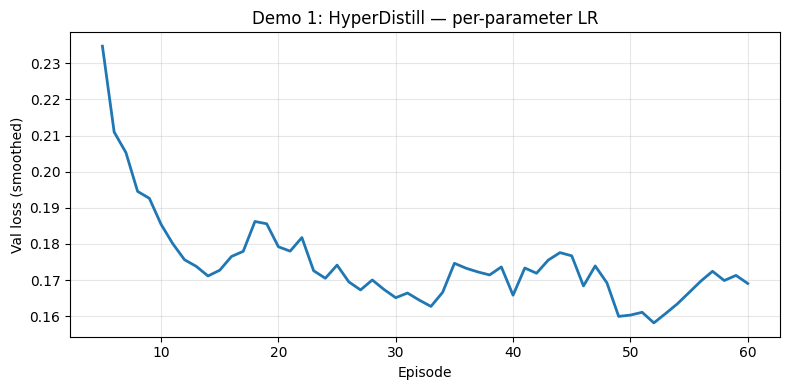

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
w = 5
ax.plot(range(w, M+1), smooth(hd_losses, w), lw=2, color='tab:blue')
ax.set(xlabel='Episode', ylabel='Val loss (smoothed)',
       title='Demo 1: HyperDistill — per-parameter LR')
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

---

## 2. One-Step Lookahead (`OneStepOptimizer`)


In [8]:
def train_loss_l2(params, hyperparams, batch):
    ce = cross_entropy_loss(params, batch)
    lam = jax.nn.softplus(hyperparams)
    l2 = sum(jnp.sum(jnp.square(p)) for p in jax.tree.leaves(params))
    return ce + lam * l2

def val_loss_l2(params, hyperparams, batch):
    return cross_entropy_loss(params, batch)

def make_l2_update_fn(lr_inner=0.05):
    def update_fn(w, log_lam, batch):
        grads = jax.grad(train_loss_l2)(w, log_lam, batch)
        return jax.tree.map(lambda wi, gi: wi - lr_inner * gi, w, grads)
    return update_fn

In [9]:
os_losses, os_lam_hist = [], []
log_lam_init = jnp.array(float(jnp.log(jnp.exp(1e-3) - 1.0)))
update_fn_l2 = make_l2_update_fn(0.05)

def os_cb(ep, state):
    loss, acc = evaluate(state.params, X_val, Y_val)
    os_losses.append(loss)
    eff = float(jax.nn.softplus(state.hyperparams))
    os_lam_hist.append(eff)
    if ep % 10 == 0: print(f'  ep {ep:3d}  loss={loss:.4f}  acc={acc:.2%}  lam={eff:.6f}')

k1, k2 = jax.random.split(jax.random.PRNGKey(SEED + 200))
gt = BatchIterator(X_train, Y_train, BATCH_SIZE, k1)
gv = BatchIterator(X_val, Y_val, BATCH_SIZE, k2)

os_opt = OneStepOptimizer(update_fn=update_fn_l2)
os_state = os_opt.init(w_init, log_lam_init)

print('Running OneStep (L2 tuning) ...')
os_state = os_opt.run(os_state, M, T, gt, gv,
    train_loss_l2, val_loss_l2,
    lr_reptile=LR_REPTILE, lr_hyper=0.01, callback=os_cb)
print(f'Best val loss = {min(os_losses):.4f}')
print(f'Final lambda = {float(jax.nn.softplus(os_state.hyperparams)):.6f}')

Running OneStep (L2 tuning) ...
  ep  10  loss=0.1739  acc=99.50%  lam=0.001000
  ep  20  loss=0.1620  acc=100.00%  lam=0.001000
  ep  30  loss=0.1789  acc=100.00%  lam=0.001000
  ep  40  loss=0.1630  acc=100.00%  lam=0.001000
  ep  50  loss=0.1615  acc=100.00%  lam=0.001000
  ep  60  loss=0.1719  acc=100.00%  lam=0.001000
Best val loss = 0.1546
Final lambda = 0.001000


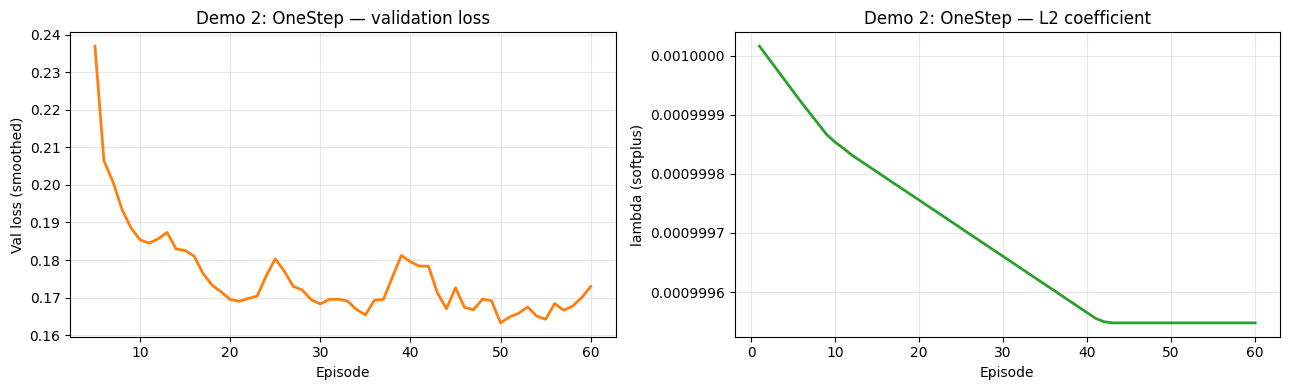

In [10]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
w = 5
a1.plot(range(w, M+1), smooth(os_losses, w), lw=2, color='tab:orange')
a1.set(xlabel='Episode', ylabel='Val loss (smoothed)',
       title='Demo 2: OneStep — validation loss')
a1.grid(alpha=0.3)
a2.plot(range(1, M+1), os_lam_hist, lw=2, color='tab:green')
a2.set(xlabel='Episode', ylabel='lambda (softplus)',
       title='Demo 2: OneStep — L2 coefficient')
a2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---

## 3. First-Order Baseline (`FOOptimizer`)

The FO baseline ignores the second-order term entirely.

**Toy task:** data hyper-cleaning — per-sample weights on noisy data.

In [11]:
N_TRAIN_HC = 300; NOISE_RATE = 0.3
k_hc_tr, k_hc_va = jax.random.split(jax.random.PRNGKey(SEED + 500))
X_train_hc, Y_train_hc = make_data(
    k_hc_tr, centres, N_TRAIN_HC, N_CLASSES, noise_rate=NOISE_RATE)
X_val_hc, Y_val_hc = make_data(
    k_hc_va, centres, 200, N_CLASSES, noise_rate=0.0)
X_hc_full = jnp.array(X_train_hc)
Y_hc_full = jnp.array(Y_train_hc)
print(f'Train: {N_TRAIN_HC} ({NOISE_RATE:.0%} noise), Val: {X_val_hc.shape[0]} (clean)')

Train: 300 (30% noise), Val: 200 (clean)


In [12]:
def weighted_train_loss(params, sample_weights, batch):
    indices = batch[0]
    x, y = X_hc_full[indices], Y_hc_full[indices]
    logits = mlp_forward(params, x)
    log_probs = jax.nn.log_softmax(logits, axis=-1)
    per_sample = -jnp.sum(log_probs * y, axis=-1)
    w = jax.nn.sigmoid(sample_weights[indices])
    return jnp.mean(w * per_sample)

def weighted_val_loss(params, sample_weights, batch):
    x, y = batch
    logits = mlp_forward(params, x)
    log_probs = jax.nn.log_softmax(logits, axis=-1)
    return -jnp.mean(jnp.sum(log_probs * y, axis=-1))

def make_weighted_update_fn(lr_inner=0.05):
    def update_fn(w, sw, batch):
        grads = jax.grad(weighted_train_loss)(w, sw, batch)
        return jax.tree.map(lambda wi, gi: wi - lr_inner * gi, w, grads)
    return update_fn

class IndexBatchIterator:
    def __init__(self, n, batch_size, key):
        self.n, self.bs, self.key = n, batch_size, key
    def __call__(self):
        self.key, sk = jax.random.split(self.key)
        return (jax.random.randint(sk, (self.bs,), 0, self.n),)

In [13]:
fo_losses = []
sw_init = jnp.zeros(N_TRAIN_HC)
update_fn_hc = make_weighted_update_fn(0.05)

def fo_cb(ep, state):
    loss, acc = evaluate(state.params, X_val_hc, Y_val_hc)
    fo_losses.append(loss)
    if ep % 10 == 0:
        sw = jax.nn.sigmoid(state.hyperparams)
        print(f'  ep {ep:3d}  loss={loss:.4f}  acc={acc:.2%}  '
              f'mean_w={float(jnp.mean(sw)):.3f}')

k1, k2 = jax.random.split(jax.random.PRNGKey(SEED + 400))
gt = IndexBatchIterator(N_TRAIN_HC, BATCH_SIZE, k1)
gv = BatchIterator(X_val_hc, Y_val_hc, BATCH_SIZE, k2)

fo_opt = FOOptimizer(update_fn=update_fn_hc)
fo_state = fo_opt.init(w_init, sw_init)

print('Running FOOptimizer (data hyper-cleaning) ...')
fo_state = fo_opt.run(fo_state, M, T, gt, gv,
    weighted_train_loss, weighted_val_loss,
    lr_reptile=LR_REPTILE, lr_hyper=0.05, callback=fo_cb)
print(f'Best val loss = {min(fo_losses):.4f}')

Running FOOptimizer (data hyper-cleaning) ...
  ep  10  loss=0.3678  acc=98.00%  mean_w=0.500
  ep  20  loss=0.3606  acc=99.00%  mean_w=0.500
  ep  30  loss=0.3646  acc=98.50%  mean_w=0.500
  ep  40  loss=0.3375  acc=99.00%  mean_w=0.500
  ep  50  loss=0.3370  acc=98.00%  mean_w=0.500
  ep  60  loss=0.3237  acc=98.00%  mean_w=0.500
Best val loss = 0.3237


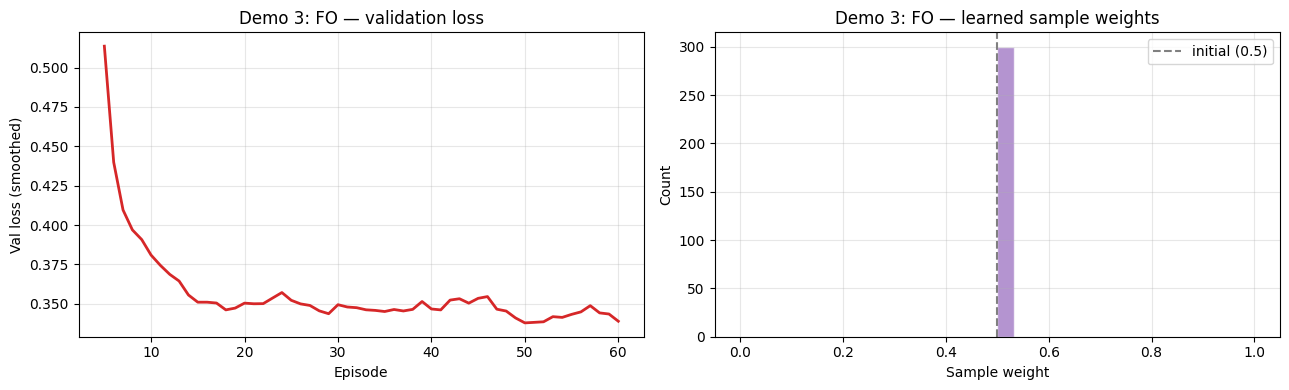

In [14]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
w = 5
a1.plot(range(w, M+1), smooth(fo_losses, w), lw=2, color='tab:red')
a1.set(xlabel='Episode', ylabel='Val loss (smoothed)',
       title='Demo 3: FO — validation loss')
a1.grid(alpha=0.3)

sw_final = np.array(jax.nn.sigmoid(fo_state.hyperparams))
a2.hist(sw_final, bins=30, color='tab:purple', alpha=0.7, edgecolor='white')
a2.axvline(0.5, color='grey', ls='--', label='initial (0.5)')
a2.set(xlabel='Sample weight', ylabel='Count',
       title='Demo 3: FO — learned sample weights')
a2.legend(); a2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---



## 4. T1-T2 Optimizer (`T1T2Optimizer`)



**T1-T2** (Luketina et al., 2016) uses a numerical DARTS approximation

to compute the second-order hypergradient term efficiently.



**Toy task:** per-parameter learning rate optimisation (same as Demo 1).

In [4]:
t1t2_losses = []

def t1t2_cb(ep, state):
    loss, acc = evaluate(state.params, X_val, Y_val)
    t1t2_losses.append(loss)
    if ep % 10 == 0: print(f'  ep {ep:3d}  loss={loss:.4f}  acc={acc:.2%}')


k1, k2 = jax.random.split(jax.random.PRNGKey(SEED + 700))
gt_t1t2 = BatchIterator(X_train, Y_train, BATCH_SIZE, k1)
gv_t1t2 = BatchIterator(X_val, Y_val, BATCH_SIZE, k2)

t1t2_opt = T1T2Optimizer(update_fn=update_fn, gamma=GAMMA, T=T)
t1t2_state = t1t2_opt.init(w_init, lam_init)

print('Running T1T2 ...')
t1t2_state = t1t2_opt.run(
    t1t2_state, M, gt_t1t2, gv_t1t2,
    cross_entropy_loss_bilevel, cross_entropy_loss_bilevel,
    lr_reptile=LR_REPTILE, lr_hyper=LR_HYPER, callback=t1t2_cb)
print(f'Best val loss = {min(t1t2_losses):.4f}')

Running T1T2 ...
  ep  10  loss=0.1848  acc=99.50%


KeyboardInterrupt: 

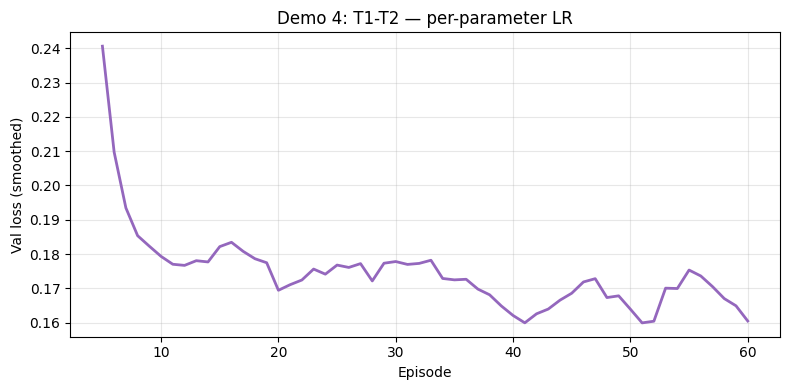

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
w = 5
ax.plot(range(w, M+1), smooth(t1t2_losses, w), lw=2, color='tab:purple')
ax.set(xlabel='Episode', ylabel='Val loss (smoothed)',
       title='Demo 4: T1-T2 — per-parameter LR')
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

---



## 5. Greedy Gradient Optimizer (`GreedyOptimizer`)



**Greedy** (Eq. 6 from the paper) approximates the hypergradient as a

discount-weighted sum of local greedy terms over the unrolled inner steps.



**Toy task:** per-parameter learning rate optimisation (same as Demo 1).

In [16]:
import optax as _optax  # alias to avoid shadowing

greedy_losses = []

def greedy_cb(ep, state):
    loss, acc = evaluate(state.params, X_val, Y_val)
    greedy_losses.append(loss)
    if ep % 10 == 0: print(f'  ep {ep:3d}  loss={loss:.4f}  acc={acc:.2%}')


k1, k2 = jax.random.split(jax.random.PRNGKey(SEED + 800))
gt_gr = BatchIterator(X_train, Y_train, BATCH_SIZE, k1)
gv_gr = BatchIterator(X_val, Y_val, BATCH_SIZE, k2)

# GreedyOptimizer requires an outer_optimizer (uses optax.adam)
greedy_opt = GreedyOptimizer(
    inner_optimizer=_optax.sgd(LR_HYPER),
    outer_optimizer=_optax.adam(LR_HYPER),
    unroll_steps=T,
    gamma=GAMMA,
)

# Build a custom update_fn-compatible inner step for GreedyOptimizer
# GreedyOptimizer uses train_loss_fn(params, hyperparams, batch) directly
# and its inner_optimizer for the inner step — we pass the bilevel loss.
greedy_state = greedy_opt.init(w_init, lam_init)

print('Running Greedy ...')
greedy_state = greedy_opt.run(
    greedy_state, M, gt_gr, gv_gr,
    cross_entropy_loss_bilevel, cross_entropy_loss_bilevel,
    lr_reptile=LR_REPTILE, callback=greedy_cb)
print(f'Best val loss = {min(greedy_losses):.4f}')

Running Greedy ...
  ep  10  loss=0.4623  acc=93.50%
  ep  20  loss=0.2838  acc=98.00%
  ep  30  loss=0.2586  acc=99.00%
  ep  40  loss=0.2147  acc=99.50%
  ep  50  loss=0.2081  acc=99.50%
  ep  60  loss=0.1977  acc=99.50%
Best val loss = 0.1977


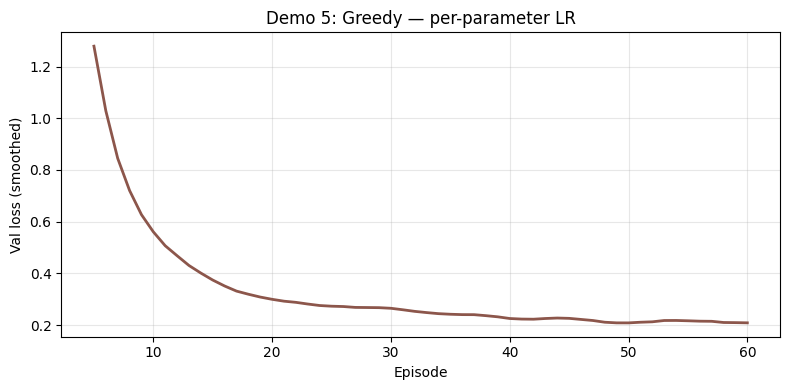

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
w = 5
ax.plot(range(w, M+1), smooth(greedy_losses, w), lw=2, color='tab:brown')
ax.set(xlabel='Episode', ylabel='Val loss (smoothed)',
       title='Demo 5: Greedy — per-parameter LR')
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

---



## 6. Comparison on the same task



All five optimizers + fixed-LR baseline on the per-parameter LR task.

In [18]:
def run_fixed_lr(w0, lam, T, M, lr_r, ufn, gt, gv, Xv, Yv):
    phi, losses = w0, []
    for m in range(1, M+1):
        w = phi
        for _ in range(T): w = ufn(w, lam, gt())
        phi = jax.tree.map(lambda p, wt: p - lr_r*(p-wt), phi, w)
        losses.append(evaluate(w, Xv, Yv)[0])
    return losses

k1, k2 = jax.random.split(jax.random.PRNGKey(SEED + 100))
print('Running Fixed-LR ...')
fixed_losses = run_fixed_lr(w_init, lam_init, T, M, LR_REPTILE,
    update_fn, BatchIterator(X_train, Y_train, BATCH_SIZE, k1),
    BatchIterator(X_val, Y_val, BATCH_SIZE, k2), X_val, Y_val)
print(f'Best = {min(fixed_losses):.4f}')

Running Fixed-LR ...
Best = 0.1488


In [19]:
os2_losses = []
def os2_cb(ep, s): os2_losses.append(evaluate(s.params, X_val, Y_val)[0])

k1, k2 = jax.random.split(jax.random.PRNGKey(SEED + 200))
os2 = OneStepOptimizer(update_fn=update_fn)
os2_s = os2.init(w_init, lam_init)
print('Running OneStep ...')
os2.run(os2_s, M, T,
    BatchIterator(X_train, Y_train, BATCH_SIZE, k1),
    BatchIterator(X_val, Y_val, BATCH_SIZE, k2),
    cross_entropy_loss_bilevel, cross_entropy_loss_bilevel,
    lr_reptile=LR_REPTILE, lr_hyper=LR_HYPER, callback=os2_cb)
print(f'Best = {min(os2_losses):.4f}')

Running OneStep ...
Best = 0.1527


In [20]:
fo2_losses = []
def fo2_cb(ep, s): fo2_losses.append(evaluate(s.params, X_val, Y_val)[0])

k1, k2 = jax.random.split(jax.random.PRNGKey(SEED + 150))
fo2 = FOOptimizer(update_fn=update_fn)
fo2_s = fo2.init(w_init, lam_init)
print('Running FO ...')
fo2.run(fo2_s, M, T,
    BatchIterator(X_train, Y_train, BATCH_SIZE, k1),
    BatchIterator(X_val, Y_val, BATCH_SIZE, k2),
    cross_entropy_loss_bilevel, cross_entropy_loss_bilevel,
    lr_reptile=LR_REPTILE, lr_hyper=LR_HYPER, callback=fo2_cb)
print(f'Best = {min(fo2_losses):.4f}')

Running FO ...
Best = 0.1563


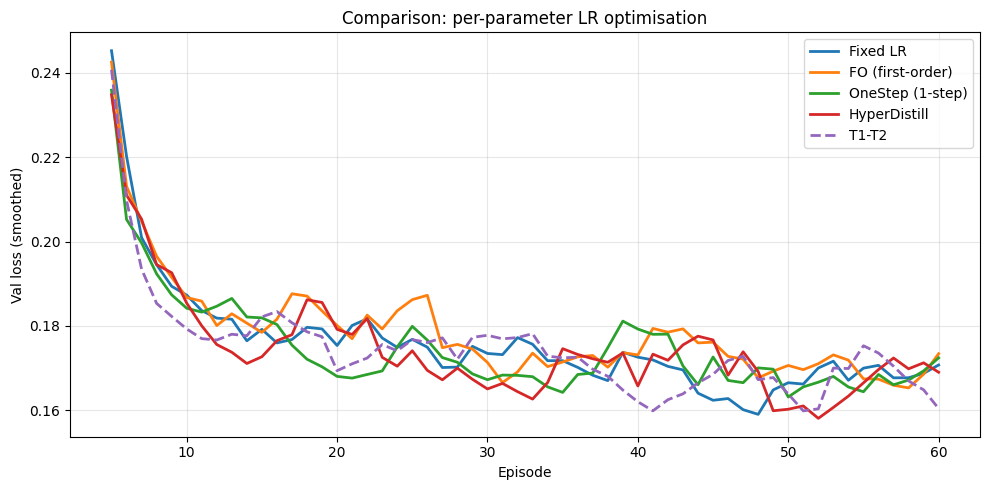

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
w = 5; eps_s = range(w, M+1)
ax.plot(eps_s, smooth(fixed_losses, w), lw=2, label='Fixed LR')
ax.plot(eps_s, smooth(fo2_losses, w), lw=2, label='FO (first-order)')
ax.plot(eps_s, smooth(os2_losses, w), lw=2, label='OneStep (1-step)')
ax.plot(eps_s, smooth(hd_losses, w), lw=2, label='HyperDistill')
ax.plot(eps_s, smooth(t1t2_losses, w), lw=2, label='T1-T2', linestyle='--')
# ax.plot(eps_s, smooth(greedy_losses, w), lw=2, label='Greedy', linestyle=':')
ax.set(xlabel='Episode', ylabel='Val loss (smoothed)',
       title='Comparison: per-parameter LR optimisation')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()